In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression,Ridge

In [41]:
import sklearn
print("numpy: ",np.__version__)
print("pandas: ",pd.__version__)
print("sklearn: ",sklearn.__version__)

numpy:  2.3.5
pandas:  2.3.3
sklearn:  1.7.2


In [2]:
df=pd.read_csv("insurance.csv")

In [3]:
df1=df.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df[["charges"]]=np.round(df[["charges"]],2)
print(df.head())

   age     sex     bmi  children smoker     region   charges
0   19  female  27.900         0    yes  southwest  16884.92
1   18    male  33.770         1     no  southeast   1725.55
2   28    male  33.000         3     no  southeast   4449.46
3   33    male  22.705         0     no  northwest  21984.47
4   32    male  28.880         0     no  northwest   3866.86


In [7]:
headers=["age","gender","bmi","children","is_smoker","region","charges"]
df.columns=headers

In [8]:
df.replace('?',np.nan,inplace=True)

In [9]:
smokes=df["is_smoker"].value_counts().max()
df['is_smoker'].replace(np.nan,smokes,inplace=True)
mean_age=df['age'].astype('float').mean(axis=0)
df["age"].replace(np.nan,mean_age,inplace=True)

# Regression plot for charges with respect to bmi

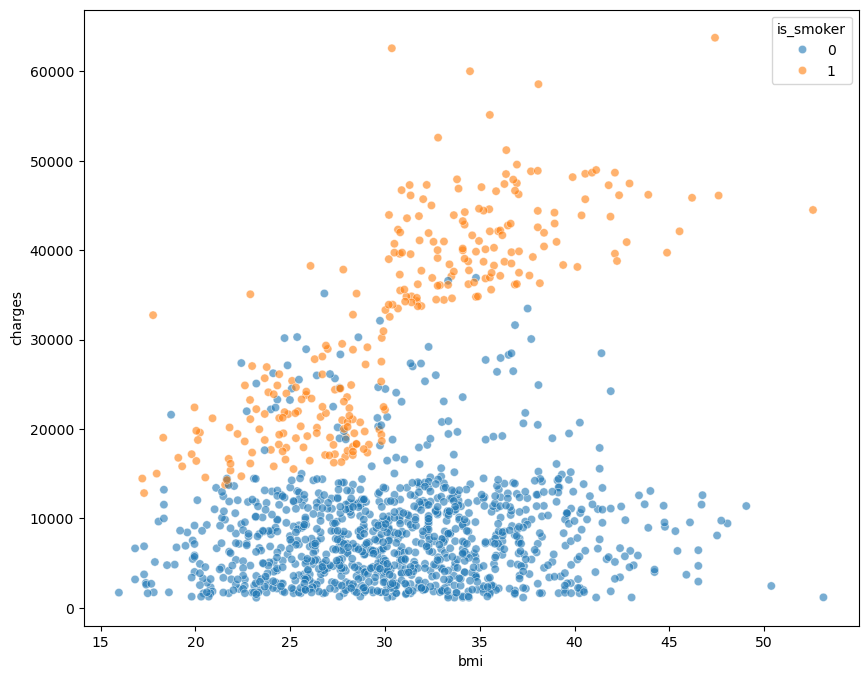

In [43]:
plt.figure(figsize=(10,8))
sns.scatterplot(x="bmi",y="charges",hue="is_smoker",data=df,alpha=0.6)
plt.show()

## The scatter plot indicates that individuals who smoke tend to have significantly higher insurance charges. This effect becomes more pronounced as BMI increases, suggesting that smoking combined with higher BMI leads to substantially greater medical costs.
## Non-smokers show relatively lower charges even with higher BMI. The plot suggests that Smoking has higher influence on insurance cost than BMI.

# Distribution of Charges based on Region using Violin Plot

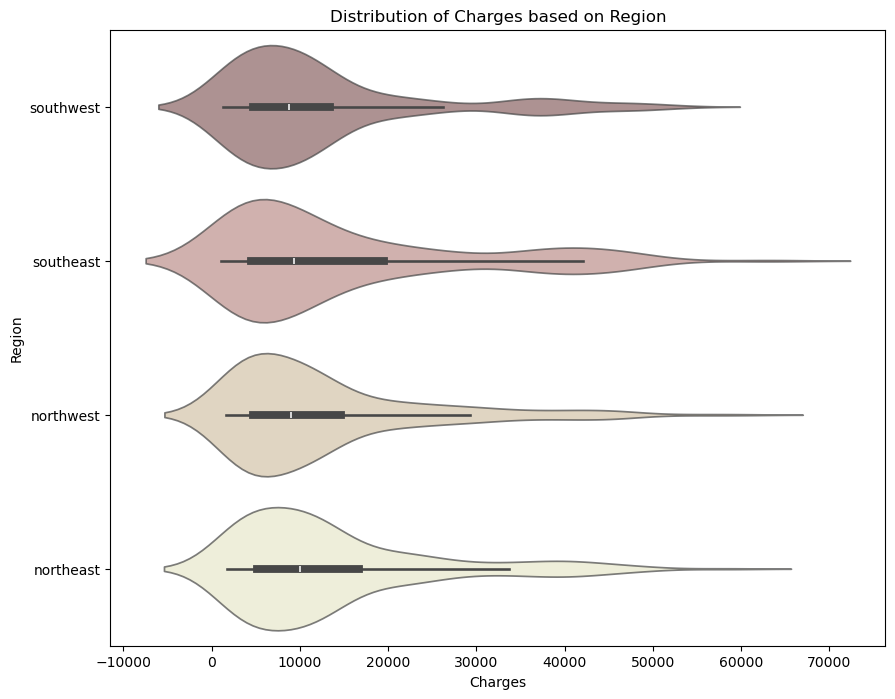

In [11]:
plt.figure(figsize=(10,8))
sns.violinplot(x="charges",y="region",data=df,palette='pink',alpha=0.7)
plt.title("Distribution of Charges based on Region")
plt.xlabel("Charges")
plt.ylabel("Region")
plt.show()

## The median charges for all four regions appear relatively close (around 10k–15k). This suggests <b>region alone does not strongly influence insurance charges</b>. Southeast region shows slightly higher variability. The southeast violin is wider and extends farther to the right. This indicates <b> more high-cost cases and greater spread in medical charges in Southeast region.</b> The Violin Plot above suggests that <b>geographic region has limited influence on insurance charges</b> compared to other factors.

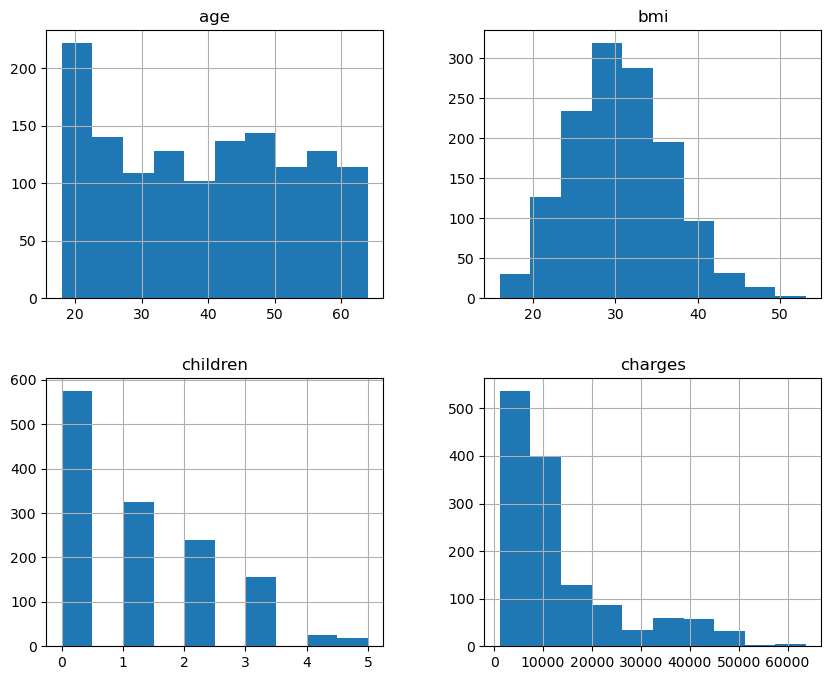

In [12]:
df.hist(figsize=(10,8))
plt.show()

### Since machine learning models cannot understand categorical data

In [13]:
df["gender"] = df["gender"].map({"male":0, "female":1})
df["region"] = df["region"].map({
    "southwest":0,
    "southeast":1,
    "northwest":2,
    "northeast":3
})

Text(0.5, 1.0, 'Box plot for charges with respect to smokers')

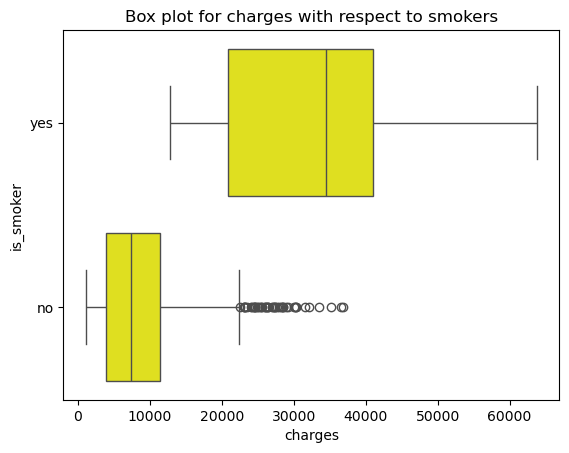

In [14]:
sns.boxplot(x="charges",y="is_smoker",data=df,color="yellow")
plt.title("Box plot for charges with respect to smokers")

## According to the Box Plot, we can observe that the Smokers have significantly higher medical charges in comparison to Non-Smokers. The median of Smokers is approximately 30,000 while for Non-Smokers the median is between 7,000 to 9,000. <b>This indicates smoking is strongly associated with higher insurance costs.</b>
## The interquartile range(IQR) for smokers(yes) is much wider than non-smokers(no), this means smoking charges are more spread out and have higher variability in medical expenses.
## Several outliers appear above ~20,000 for non-smokers. These could correspond to individuals with serious medical conditions, high BMI, or older age. 

## There is minimal overlap between the two distributions, suggesting <b> smoking is a strong predictor of insurance charges.</b>

In [15]:
df["is_smoker"]=df["is_smoker"].map({"no":0,"yes":1})

In [16]:
X=df[['is_smoker']]
y=df['charges']
lm=LinearRegression()
lm.fit(X,y)
print(lm.score(X,y))

0.6197648159343432


In [17]:
df[["age","gender","bmi","children","is_smoker","region"]].isna().sum()

age          0
gender       0
bmi          0
children     0
is_smoker    0
region       0
dtype: int64

In [18]:
import pandas as pd
from sklearn.linear_model import LinearRegression

Z = df[["age","gender","bmi","children","is_smoker","region"]]
y = df["charges"]

Z = pd.get_dummies(Z, drop_first=True)

lm = LinearRegression()
lm.fit(Z, y)

print(lm.score(Z, y))

0.7507372037225299


In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)

In [20]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import confusion_matrix

In [21]:
models={
    "LR":LinearRegression(),
    "RF":RandomForestRegressor(n_estimators=100,max_depth=7),
    "DT":DecisionTreeRegressor(),
    "GradientBoosting":GradientBoostingRegressor(n_estimators=100,max_depth=7),
    "KNN":KNeighborsRegressor(),
    "SVR":SVR()
}

In [22]:
from sklearn import preprocessing
label_encoder=preprocessing.LabelEncoder()

In [23]:
df['gender']=label_encoder.fit_transform(df['gender'])
df['is_smoker']=label_encoder.fit_transform(df['is_smoker'])
df['region']=label_encoder.fit_transform(df['region'])

In [24]:
model_performance=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    score=model.score(X_test,y_test)
    mse=mean_squared_error(y_test,y_pred)
    mae=mean_absolute_error(y_test,y_pred)

    model_performance.append({
    'Model':name,
    'Score':score,
    'Mean Squared Error':mse,
    'Mean Absolute Error':mae
    })

In [25]:
performance_df=pd.DataFrame(model_performance)
performance_df

,Model,Score,Mean Squared Error,Mean Absolute Error
0,LR,0.638207,4.991133e+07,5493.854818
1,RF,0.638185,4.991424e+07,5495.000121
2,DT,0.638207,4.991133e+07,5493.854818
3,GradientBoosting,0.638206,4.991136e+07,5493.881800
4,KNN,0.630351,5.099506e+07,5687.442716
5,SVR,-0.051240,1.450242e+08,8191.724438


In [26]:
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
print("Train score:",lm.score(X_train,y_train))
print("Test score:",lm.score(X_test,y_test))

Train score: 0.6177746445908325
Test score: 0.6382065248028846


## Since the  R2 scores are very close, indicates the model generalizes well and there is no overfitting.

In [28]:
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lm.coef_
})

,Feature,Coefficient
0,is_smoker,23601.67431


## According to the above code, is_smoker affects the prediction the most

In [29]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
pred=lm.predict(X_test)
print("MAE:",mean_absolute_error(y_test,pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))


MAE: 5531.098974935033
RMSE: 7080.937477917565


In [31]:
df["smoker_bmi"] = df["is_smoker"] * df["bmi"]
df["smoker_age"] = df["is_smoker"] * df["age"]

In [32]:
X = df[['age','gender','bmi','children','is_smoker','region','smoker_bmi','smoker_age']]
y = df['charges']

## Regularized regression

In [33]:
#Ridge Regression
model=Ridge(alpha=1.0)
model.fit(X_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [34]:
#Lasso Regression
from sklearn.linear_model import Lasso
model=Lasso(alpha=0.1)
model.fit(X_train,y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


# RESIDUAL ANALYSIS (Final Refinement Check)

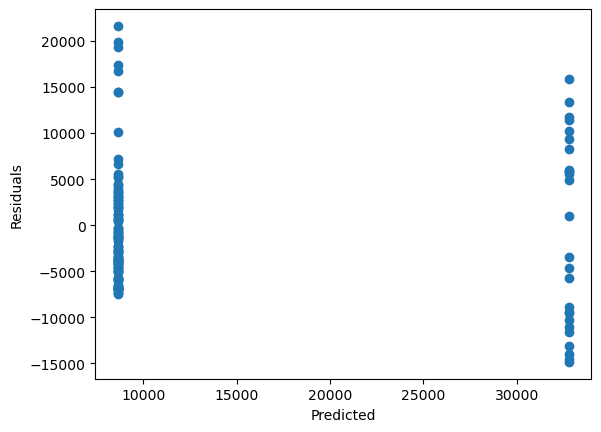

In [35]:
import matplotlib.pyplot as pt
plt.scatter(pred,y_test-pred)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

In [36]:
X = df[["age","gender","bmi","children","is_smoker","region"]]
y = df["charges"]

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

from sklearn.linear_model import Ridge
model = Ridge(alpha=1)

model.fit(X_train,y_train)

print(model.score(X_test,y_test))

0.7830849046996257


In [37]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

print(rf.score(X_test, y_test))

0.8663026908553768


### Based on the evaluation metrics, it is reasonable to conclude that Random Forest is a better-fitted model for this dataset than Linear Regression, provided its performance metrics are higher.

# Linear regression assumes straight-line relationships.

# Random Forest uses many decision trees and can capture complex patterns in the data.

# Model Deployment

In [39]:
import pickle
with open('insurance__model.pkl','wb') as file:
    pickle.dump(rf,file)